# **GitHub Portfolio: Predictive Analytics Storytelling**
*Maxwell Martin*

*Prof Hasan Arslan*

*ISOM 835 — Predictive Analytics | Sawyer Business School*

*March 16, 2026*




# **LOADING THE DATA**

In [38]:
# CLIENT B: Bank Marketing Campaign

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=222)
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} clients, {df.shape[1]} columns")
df.head()

Dataset loaded: 45,211 clients, 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


# **THE SITUATION**

In [39]:
print("Dataset shape:", df.shape)

df.info()

print("\nMissing values by column:")
print(df.isnull().sum())

print("\nTarget variable distribution:")
print(df['y'].value_counts())

print("\nTarget variable percentage:")
print(df['y'].value_counts(normalize=True) * 100)

df.describe()


Dataset shape: (45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Missing values by column:
age    

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


**Client Briefing — The Situation:**

The dataset contains 45,211 client records and 17 variables describing customer demographics, financial information, and details from previous marketing campaigns. The target variable indicates whether a client subscribed to a term deposit, and the outcome is highly imbalanced, with about 88% of customers not subscribing and only roughly 12% subscribing. The data also contains missing values in several columns, most notably poutcome and contact, which will need to be addressed before modeling. Overall, the dataset provides a strong sample size for analysis, but some preprocessing will be required to handle missing data and prepare the variables for predictive modeling.



---

# **THE DISCOVERY**

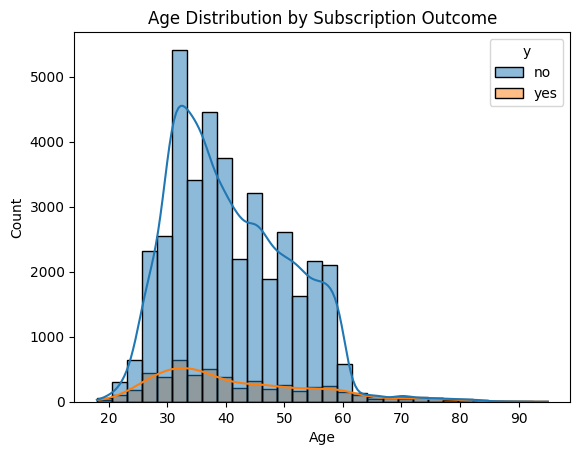

In [40]:
# Age vs Subscription Outcome

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='age', hue='y', bins=30, kde=True)
plt.title("Age Distribution by Subscription Outcome")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


**Finding 1:**

The age distribution shows that most customers fall between their early 30s and mid-50s. While the overall distribution is similar for both groups, customers who subscribed to the term deposit appear slightly older on average than those who did not subscribe. This suggests that older clients may be more interested in long-term savings products, making them a potentially stronger target segment for Client B's marketing campaigns.



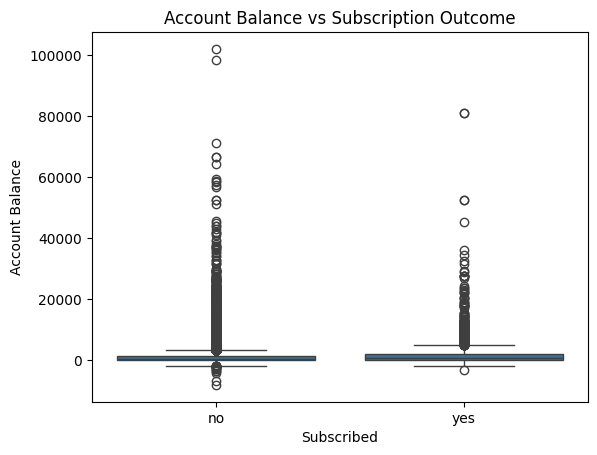

In [41]:
# Account Balance vs Subscription Outcome

sns.boxplot(x='y', y='balance', data=df)
plt.title("Account Balance vs Subscription Outcome")
plt.xlabel("Subscribed")
plt.ylabel("Account Balance")
plt.show()

**Finding 2:**

The distribution of account balances shows that customers who subscribed to the term deposit generally have slightly higher balances than those who did not subscribe. While there are several extreme values in both groups, the overall median balance appears higher among subscribers. This suggests that customers with greater available funds may be more willing to commit money to longer-term savings products, making them a promising group for the bank to target in future campaigns.



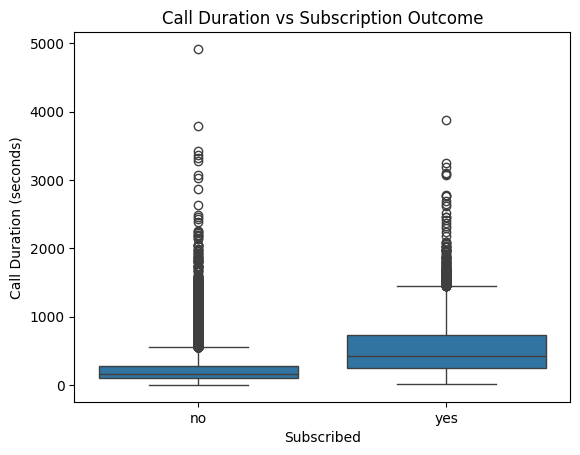

In [42]:
# Call Duration vs Subscription Outcome

sns.boxplot(x='y', y='duration', data=df)
plt.title("Call Duration vs Subscription Outcome")
plt.xlabel("Subscribed")
plt.ylabel("Call Duration (seconds)")
plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)
plt.show()

**Finding 3:**

Call duration appears to have a strong relationship with whether a customer subscribes to a term deposit. Customers who ultimately subscribed generally had much longer conversations with bank representatives compared to those who did not subscribe. This suggests that successful conversions may require more detailed discussions about the product, highlighting the importance of effective communication during the call.



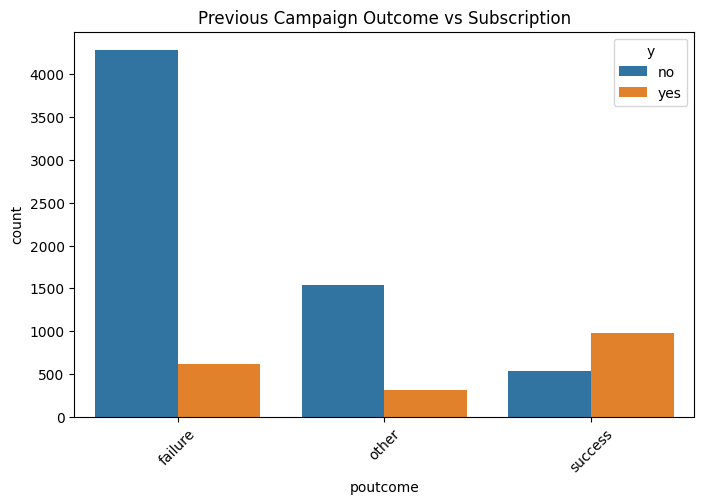

poutcome  y  
failure   no     0.873903
          yes    0.126097
other     no     0.833152
          yes    0.166848
success   yes    0.647253
          no     0.352747
Name: proportion, dtype: float64

In [43]:
# Previous Campaign Outcome vs Subscription Outcome

plt.figure(figsize=(8,5))
sns.countplot(x='poutcome', hue='y', data=df)
plt.title("Previous Campaign Outcome vs Subscription")
plt.xticks(rotation=45)
plt.show()

df.groupby('poutcome')['y'].value_counts(normalize=True)

**Finding 4:**

The results show a strong relationship between previous campaign outcomes and whether a customer subscribes to a term deposit. Customers who previously responded successfully to a marketing campaign are far more likely to subscribe again compared to those whose previous outcome was a failure or another result. This suggests that prior campaign success may be one of the strongest indicators of future subscription behavior, making these customers especially valuable targets for future marketing efforts.



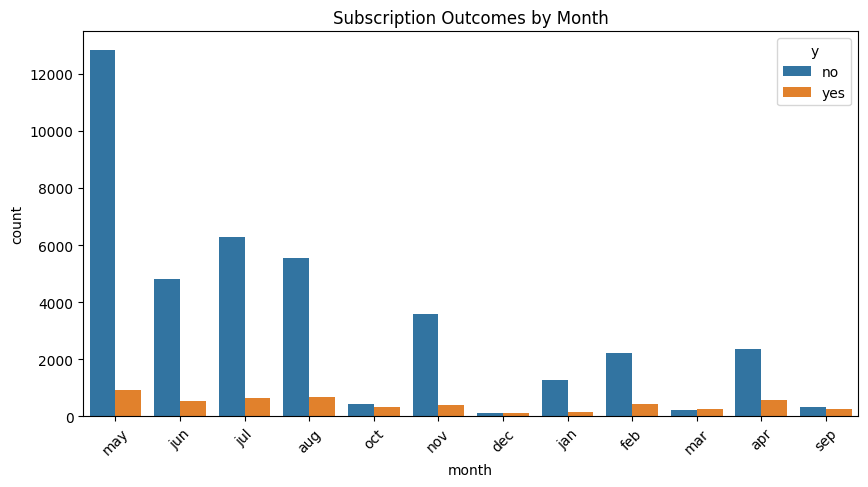

month  y  
apr    no     0.803206
       yes    0.196794
aug    no     0.889867
       yes    0.110133
dec    no     0.532710
       yes    0.467290
feb    no     0.833522
       yes    0.166478
jan    no     0.898788
       yes    0.101212
jul    no     0.909065
       yes    0.090935
jun    no     0.897772
       yes    0.102228
mar    yes    0.519916
       no     0.480084
may    no     0.932805
       yes    0.067195
nov    no     0.898489
       yes    0.101511
oct    no     0.562331
       yes    0.437669
sep    no     0.535406
       yes    0.464594
Name: proportion, dtype: float64

In [44]:
# Month vs Subscription Outcome

plt.figure(figsize=(10,5))
sns.countplot(x='month', hue='y', data=df)
plt.title("Subscription Outcomes by Month")
plt.xticks(rotation=45)
plt.show()

df.groupby('month')['y'].value_counts(normalize=True)

**Finding 5:**

Subscription outcomes vary noticeably depending on the month in which customers are contacted. Some months, such as March, December, and September, show significantly higher subscription rates compared to others. In contrast, May, despite having the largest number of calls, shows one of the lowest conversion rates. This suggests that the timing of marketing campaigns may influence customer responsiveness, and shifting outreach toward months with higher subscription rates could improve overall campaign effectiveness.



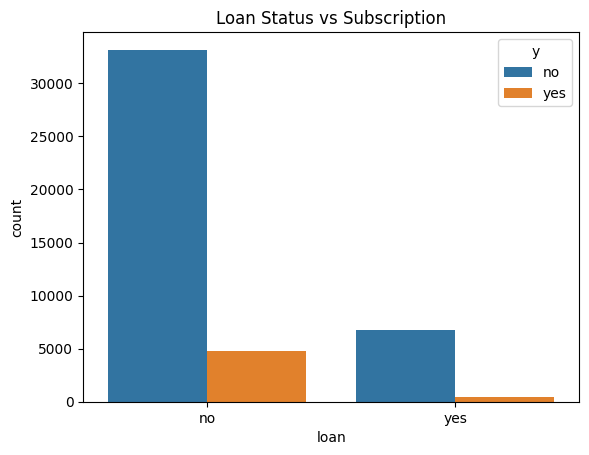

loan  y  
no    no     0.873443
      yes    0.126557
yes   no     0.933186
      yes    0.066814
Name: proportion, dtype: float64

In [45]:
# Loan Status vs Subscription Outcome

sns.countplot(x='loan', hue='y', data=df)
plt.title("Loan Status vs Subscription")
plt.show()

df.groupby('loan')['y'].value_counts(normalize=True)

**Finding 6:**

Loan status also appears to influence whether a customer subscribes to a term deposit. Customers without an existing loan show a noticeably higher subscription rate compared to those who currently have loan obligations. This may reflect differences in financial flexibility, as customers without debt may have more available funds to commit to savings products. As a result, targeting customers without active loans could improve the effectiveness of the bank’s marketing campaigns.

---

# **DATA PREPARATION**

In [46]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=222)
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)

print("Original y values:")
print(df['y'].value_counts(dropna=False))

df = df.drop(columns=['poutcome'])

for col in ['job', 'education', 'contact']:
    df[col] = df[col].fillna('unknown')

df['y'] = df['y'].map({'no': 0, 'yes': 1})

X = df.drop('y', axis=1)
y = df['y']

X = pd.get_dummies(X, drop_first=True)

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)
print("Any missing in X?", X.isnull().sum().sum())
print("Any missing in y?", y.isnull().sum())
print(y.value_counts())

Original y values:
y
no     39922
yes     5289
Name: count, dtype: int64
Feature matrix shape: (45211, 39)
Target variable shape: (45211,)
Any missing in X? 0
Any missing in y? 0
y
0    39922
1     5289
Name: count, dtype: int64


**Why these features?**

*The model uses demographic, financial, and campaign-related variables to predict whether a customer subscribes to a term deposit. The exploratory analysis in Part 2 showed that factors such as age, account balance, call duration, previous campaign outcomes, and loan status appear to influence subscription behavior. To prepare the data for modeling, categorical variables were converted into dummy variables so they could be used by the algorithm. The poutcome column was removed due to a large number of missing values, and remaining missing categorical values were filled with "unknown" to preserve the full dataset for analysis.*



---

# **GAUSSIAN NAIVE BAYES MODEL**

Accuracy: 0.8595598805706071
Confusion Matrix:
[[7270  682]
 [ 588  503]]


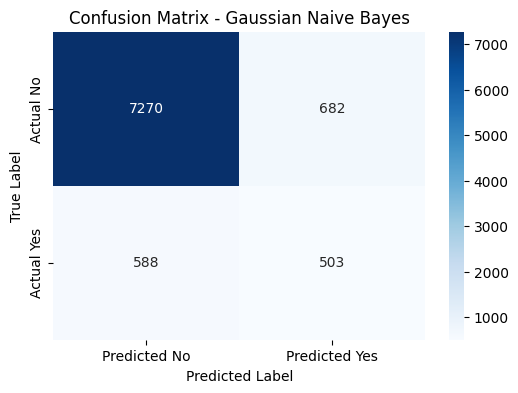

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted No', 'Predicted Yes'], yticklabels=['Actual No', 'Actual Yes'])
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Model Performance:**

The model correctly predicts customer outcomes with an overall accuracy of about 86%, meaning it can identify most customers who will and will not subscribe to a term deposit. However, the confusion matrix shows that the model still misses some potential subscribers, incorrectly predicting “no” for 588 customers who actually subscribed. At the same time, it generates 682 false positives, meaning some customers would be contacted even though they ultimately do not subscribe. For the bank, false positives represent additional marketing calls that may not lead to conversions, while false negatives represent missed opportunities to secure new deposits. Overall, the model provides a useful starting point for identifying likely outcomes, but the bank should be aware of the trade-off between reaching potential subscribers and avoiding unnecessary outreach.



**Second Model**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8894172287957536
Confusion Matrix:
[[7765  187]
 [ 813  278]]


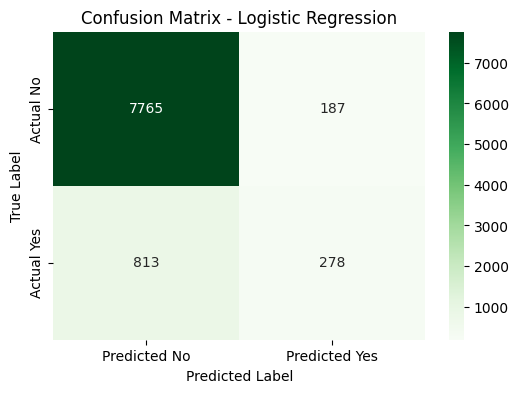

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_accuracy)

cm_log = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:")
print(cm_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens', xticklabels=['Predicted No','Predicted Yes'], yticklabels=['Actual No','Actual Yes'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


**Second Model Comparison:**

A logistic regression model was trained using the same training and testing split to compare its performance with the Gaussian Naive Bayes model. The logistic regression model achieved a slightly higher accuracy of about 89%, compared to approximately 86% for the Naive Bayes model. It also produced fewer false positives, meaning fewer customers would be contacted unnecessarily by the bank’s marketing team. However, the model missed more actual subscribers, indicating a trade-off between reducing unnecessary outreach and identifying all potential customers who may subscribe. This difference likely occurs because logistic regression can better capture relationships between variables, while Naive Bayes assumes independence between features.

---

# **Recommendations for Client B:**

**1.**
Client B should prioritize contacting customers who previously responded successfully to marketing campaigns. The analysis showed that customers with a prior successful campaign outcome had a subscription rate of about 65%, compared to roughly 13–17% for other outcomes. Focusing outreach on these customers could significantly improve conversion rates and reduce wasted marketing calls.

**2.**
Client B should focus marketing efforts on customers with higher account balances, as these clients appear more likely to subscribe to term deposits. The exploratory analysis showed that customers who subscribed generally had higher account balances than those who did not. By prioritizing financially stable customers, Client B could improve the efficiency of its marketing campaigns and increase the likelihood of converting calls into new deposits.


**3.**
Call duration showed one of the strongest relationships with successful subscriptions. Customers who ultimately subscribed tended to have significantly longer conversations with bank representatives. This suggests that investing in better training or scripts that encourage meaningful conversations could improve conversion rates during marketing calls.

**4.**
The analysis showed that subscription rates varied by month, with some months showing noticeably higher conversion rates than others. In contrast, the month with the largest number of calls did not produce the highest subscription rate. Adjusting campaign timing to focus on months with stronger conversion performance could improve marketing efficiency and increase the number of successful subscriptions.
